# PPO агент: обучение и валидация

Обучение и валидация PPO-агента для задачи составления графиков смен водителей городского общественного транспорта.

## 1. Импорт библиотек

In [77]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, clear_output

from src.config import (
    load_environment_config,
    load_ppo_agent_config,
    load_ppo_agent_train_config,
    load_ppo_agent_validate_config,
)
from src.environment import Environment
from src.ppo import PPOAgent, RolloutBuffer, Transition
from src.models import (
    Trip, Lunch, Route, Shift, Analytics, ValidateResult
)

## 2. Загрузка конфигураций

In [78]:
CONFIG_DIR = "src/config"

env_config = load_environment_config(f"{CONFIG_DIR}/environment.yaml")
agent_config = load_ppo_agent_config(f"{CONFIG_DIR}/ppo_agent.yaml")
train_config = load_ppo_agent_train_config(f"{CONFIG_DIR}/ppo_train.yaml")
validate_config = load_ppo_agent_validate_config(f"{CONFIG_DIR}/ppo_validate.yaml")

print("=== Environment Config ===")
print(env_config)
print()
print("=== PPO Agent Config ===")
print(agent_config)
print()
print("=== Train Config ===")
print(train_config)
print()
print("=== Validate Config ===")
print(validate_config)

=== Environment Config ===
EnvironmentConfig(shifts=ShiftsConfig(shift_duration=480, work_duration_before_lunch=240, lunch_duration=45, min_rest_duration=3), control_points=ControlPointsConfig(short_term_horizon=300), target_bus_set_size=8, reward=RewardConfig(final_buses=4.0, final_deadhead=0.1, step_unused_penalty=4.0, step_deadhead_penalty=0.1, step_rest_reward=2.5, step_demand_penalty=1.0), bus_fleet_size=260, schedule_data_path='../../data/schedule_obninsk.json')

=== PPO Agent Config ===
PPOAgentConfig(hidden_layers=[128, 64, 32], activation='relu', learning_rate=1e-05, gamma=0.99, clip_epsilon=0.1, gae_lambda=0.95, epochs=4, mini_batch_size=128, rollout_steps=1024, entropy_coef=0.01, value_coef=0.5, max_grad_norm=0.5)

=== Train Config ===
PPOAgentTrainConfig(episodes=5000, display_reward_training_plot=True, display_policy_changing_plot=False, checkpoint_folder_name='ppo_offline')

=== Validate Config ===
PPOAgentValidateConfig(number_of_runs=10)


---
## Область обучения

### 3. Создание Environment

In [79]:
env = Environment(env_config)

print(f"state_dim  = {env.state_dim()}")
print(f"action_dim = {env.action_dim()}")
print(f"episode_size = {env.get_episode_size()}")

state_dim  = 76
action_dim = 8
episode_size = 318


### 4. Создание PPOAgent

In [80]:
agent = PPOAgent(agent_config, env.state_dim(), env.action_dim())
print(f"Device: {agent.device}")
print(agent.policy)

Device: cpu
ActorCritic(
  (state_net): Sequential(
    (0): Linear(in_features=76, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (actor): Linear(in_features=32, out_features=8, bias=True)
  (critic): Linear(in_features=32, out_features=1, bias=True)
)


### 5. Обучение

In [60]:
def train(config, env, agent):
    """Обучение PPO агента."""
    checkpoint_dir = Path("checkpoints") / config.checkpoint_folder_name
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    buffer = RolloutBuffer()
    episode_rewards = []
    episode_kls = []
    best_reward = -float("inf")

    # Настройка графиков
    show_reward = config.display_reward_training_plot
    show_kl = config.display_policy_changing_plot

    if show_reward or show_kl:
        ncols = int(show_reward) + int(show_kl)
        fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
        if ncols == 1:
            axes = [axes]

    for episode in range(config.episodes):
        obs = env.reset()
        done = False
        ep_reward = 0.0
        ep_kl_values = []
        buffer.clear()

        while not done:
            action_mask = env.action_mask
            action, log_prob, value = agent.act(obs, action_mask)
            next_obs, reward, done, info = env.step(action)

            buffer.add(Transition(
                obs=obs,
                action=action,
                log_prob=log_prob,
                reward=reward,
                value=value,
                done=done,
            ))
            obs = next_obs
            ep_reward += reward

            if len(buffer) >= agent.config.rollout_steps:
                stats = agent.update(buffer)
                ep_kl_values.append(stats["approx_kl"])
                buffer.clear()

        # Обновление по остатку буфера
        if len(buffer) > 0:
            stats = agent.update(buffer)
            ep_kl_values.append(stats["approx_kl"])
            buffer.clear()

        episode_rewards.append(ep_reward)
        avg_kl = float(np.mean(ep_kl_values)) if ep_kl_values else 0.0
        episode_kls.append(avg_kl)

        # Сохранение чекпоинтов
        agent.save(str(checkpoint_dir / "last.pt"))
        if ep_reward > best_reward:
            best_reward = ep_reward
            agent.save(str(checkpoint_dir / "best.pt"))

        # Динамические графики
        if show_reward or show_kl:
            clear_output(wait=True)
            ax_idx = 0

            if show_reward:
                ax = axes[ax_idx]
                ax.clear()
                ax.plot(episode_rewards, alpha=0.4, label="reward")
                if len(episode_rewards) >= 10:
                    ma = np.convolve(
                        episode_rewards,
                        np.ones(10) / 10,
                        mode="valid",
                    )
                    ax.plot(
                        range(9, len(episode_rewards)),
                        ma,
                        label="MA-10",
                        linewidth=2,
                    )
                ax.set_xlabel("Episode")
                ax.set_ylabel("Reward")
                ax.set_title("Training Reward")
                ax.legend()
                ax.grid(True, alpha=0.3)
                ax_idx += 1

            if show_kl:
                ax = axes[ax_idx]
                ax.clear()
                ax.plot(episode_kls, label="approx_kl")
                ax.set_xlabel("Episode")
                ax.set_ylabel("KL Divergence")
                ax.set_title("Policy Change (approx KL)")
                ax.legend()
                ax.grid(True, alpha=0.3)

            fig.tight_layout()
            display(fig)

        print(
            f"Episode {episode + 1}/{config.episodes} | "
            f"reward={ep_reward:.2f} | "
            f"best={best_reward:.2f} | "
            f"approx_kl={avg_kl:.6f}"
        )

    if show_reward or show_kl:
        plt.close(fig)

    print(f"\nОбучение завершено. Лучший reward: {best_reward:.2f}")
    print(f"Чекпоинты сохранены в {checkpoint_dir}")

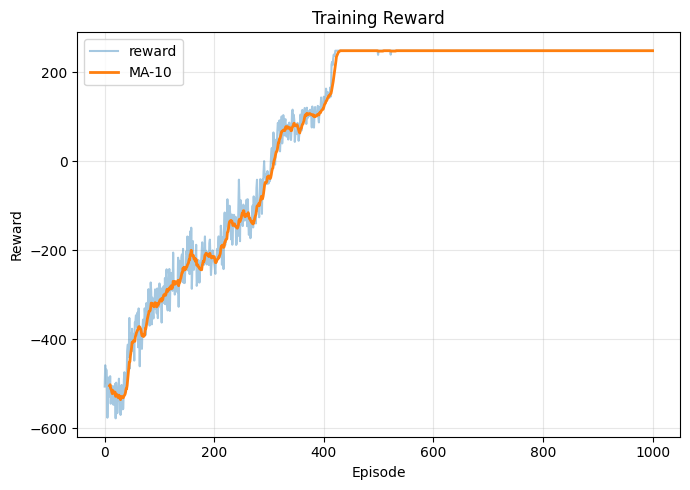

Episode 1001/5000 | reward=247.97 | best=247.97 | approx_kl=0.000000


KeyboardInterrupt: 

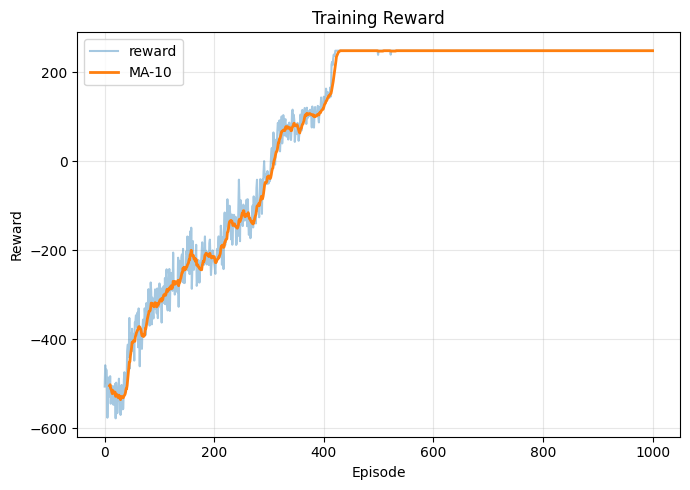

In [61]:
train(train_config, env, agent)

---
## Область валидации

### 6. Валидация

In [81]:
def validate(config, model_path) -> ValidateResult:
    """Валидация агента на нескольких независимых запусках."""
    val_env = Environment(env_config)
    val_agent = PPOAgent(agent_config, val_env.state_dim(), val_env.action_dim())
    val_agent.load(model_path)
    val_agent.policy.eval()

    accumulated_rewards = []
    final_rewards = []
    bus_used_list = []
    deadhead_list = []
    shifts_list = []

    for run in range(config.number_of_runs):
        obs = val_env.reset()
        done = False
        while not done:
            action_mask = val_env.action_mask
            action, _, _ = val_agent.act(obs, action_mask, deterministic=True)
            obs, reward, done, info = val_env.step(action)

        analytics = val_env.get_analytics()
        accumulated_rewards.append(analytics.accumulated_reward)
        final_rewards.append(analytics.final_reward)
        bus_used_list.append(analytics.total_bus_used)
        deadhead_list.append(analytics.total_deadhead_time)
        shifts_list.append(val_env.get_shifts())

        print(
            f"  Run {run + 1}/{config.number_of_runs}: "
            f"accumulated={analytics.accumulated_reward:.2f}, "
            f"final={analytics.final_reward:.2f}, "
            f"buses={analytics.total_bus_used}, "
            f"deadhead={analytics.total_deadhead_time:.1f}"
        )

    # Лучший запуск по accumulated_reward
    best_idx = int(np.argmax(accumulated_rewards))

    result = ValidateResult(
        mean_accumulated_reward=float(np.mean(accumulated_rewards)),
        mean_total_reward=float(np.mean(final_rewards)),
        best_total_bus_used=bus_used_list[best_idx],
        best_total_deadhead_time=deadhead_list[best_idx],
        best_final_reward=final_rewards[best_idx],
        best_accumulated_reward=accumulated_rewards[best_idx],
        best_shifts=shifts_list[best_idx],
    )

    print(f"\n=== Результаты валидации ===")
    print(f"Mean accumulated reward: {result.mean_accumulated_reward:.2f}")
    print(f"Mean final reward: {result.mean_total_reward:.2f}")
    print(f"Best run (#{best_idx + 1}):")
    print(f"  Buses used: {result.best_total_bus_used}")
    print(f"  Deadhead time: {result.best_total_deadhead_time:.1f}")
    print(f"  Final reward: {result.best_final_reward:.2f}")
    print(f"  Accumulated reward: {result.best_accumulated_reward:.2f}")

    return result

In [82]:
model_path = str(
    Path("checkpoints") / "ppo_offline" / "best.pt"
)
val_result = validate(validate_config, model_path)

  Run 1/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 2/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 3/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 4/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 5/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 6/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 7/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 8/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 9/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0
  Run 10/10: accumulated=247.97, final=-165.70, buses=36, deadhead=217.0

=== Результаты валидации ===
Mean accumulated reward: 247.97
Mean final reward: -165.70
Best run (#1):
  Buses used: 36
  Deadhead time: 217.0
  Final reward: -165.70
  Accumulated reward: 247.97


---
## Область визуализации лучшего запуска

### 7. Диаграмма Ганта

---
## Область визуализации лучшего запуска

### 7. Диаграмма Ганта

In [83]:
def plot_gantt(shifts, routes):
    """Диаграмма Ганта для водительских смен."""
    # Маппинг line_id -> (route_name, direction)
    line_to_route = {}
    for route in routes:
        line_to_route[route.line_id_A] = (route.name, "A")
        line_to_route[route.line_id_B] = (route.name, "B")

    # Палитра цветов для маршрутов
    route_names = sorted(set(r.name for r in routes))
    base_cmap = plt.cm.get_cmap("tab10", len(route_names))
    route_colors = {}
    for i, name in enumerate(route_names):
        base_color = np.array(base_cmap(i))
        # A -- базовый цвет, B -- более светлый оттенок
        route_colors[(name, "A")] = tuple(base_color)
        lighter = base_color * 0.6 + np.array([0.4, 0.4, 0.4, 0.0])
        lighter[3] = 1.0
        route_colors[(name, "B")] = tuple(lighter)

    lunch_color = "#AAAAAA"

    fig, ax = plt.subplots(figsize=(22, max(8, len(shifts) * 0.55)))
    ax.set_facecolor("#EAEAF2")

    y_labels = []
    for i, shift in enumerate(shifts):
        y = i
        y_labels.append(shift.bus_id)

        for event in shift.events:
            if isinstance(event, Trip):
                route_info = line_to_route.get(event.line_id)
                if route_info is None:
                    color = "gray"
                    label_text = event.line_id
                else:
                    route_name, direction = route_info
                    color = route_colors[(route_name, direction)]
                    label_text = f"{route_name}-{direction}"

                duration = event.end_time - event.start_time
                ax.barh(
                    y, duration, left=event.start_time,
                    height=0.7, color=color, edgecolor="black", linewidth=0.5,
                )
                if duration > 15:
                    ax.text(
                        event.start_time + duration / 2, y, label_text,
                        ha="center", va="center", fontsize=14,
                        fontweight="bold", color="white",
                    )

            elif isinstance(event, Lunch):
                duration = event.end_time - event.start_time
                ax.barh(
                    y, duration, left=event.start_time,
                    height=0.7, color=lunch_color, edgecolor="black", linewidth=0.5,
                )
                ax.text(
                    event.start_time + duration / 2, y, "L",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color="white",
                )

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.set_xlabel("Время (мин)", fontsize=14)
    ax.set_title("Диаграмма Ганта: смены водителей (лучший запуск)", fontsize=14)
    ax.invert_yaxis()

    # Сетка: белые линии, горизонтальные + вертикальные
    ax.grid(True, axis="x", color="white", linewidth=0.8)
    ax.set_axisbelow(True)
    for yi in range(len(y_labels)):
        ax.axhline(y=yi - 0.5, color="white", linewidth=0.5)
    ax.axhline(y=len(y_labels) - 0.5, color="white", linewidth=0.5)

    # Легенда
    legend_handles = []
    for name in route_names:
        color_a = route_colors[(name, "A")]
        color_b = route_colors[(name, "B")]
        legend_handles.append(mpatches.Patch(color=color_a, label=f"{name}-A"))
        legend_handles.append(mpatches.Patch(color=color_b, label=f"{name}-B"))
    legend_handles.append(mpatches.Patch(color=lunch_color, label="L"))
    ax.legend(
        handles=legend_handles, loc="upper right",
        fontsize=9, ncol=2, title="Bus line", title_fontsize=10,
    )

    plt.tight_layout()
    plt.show()


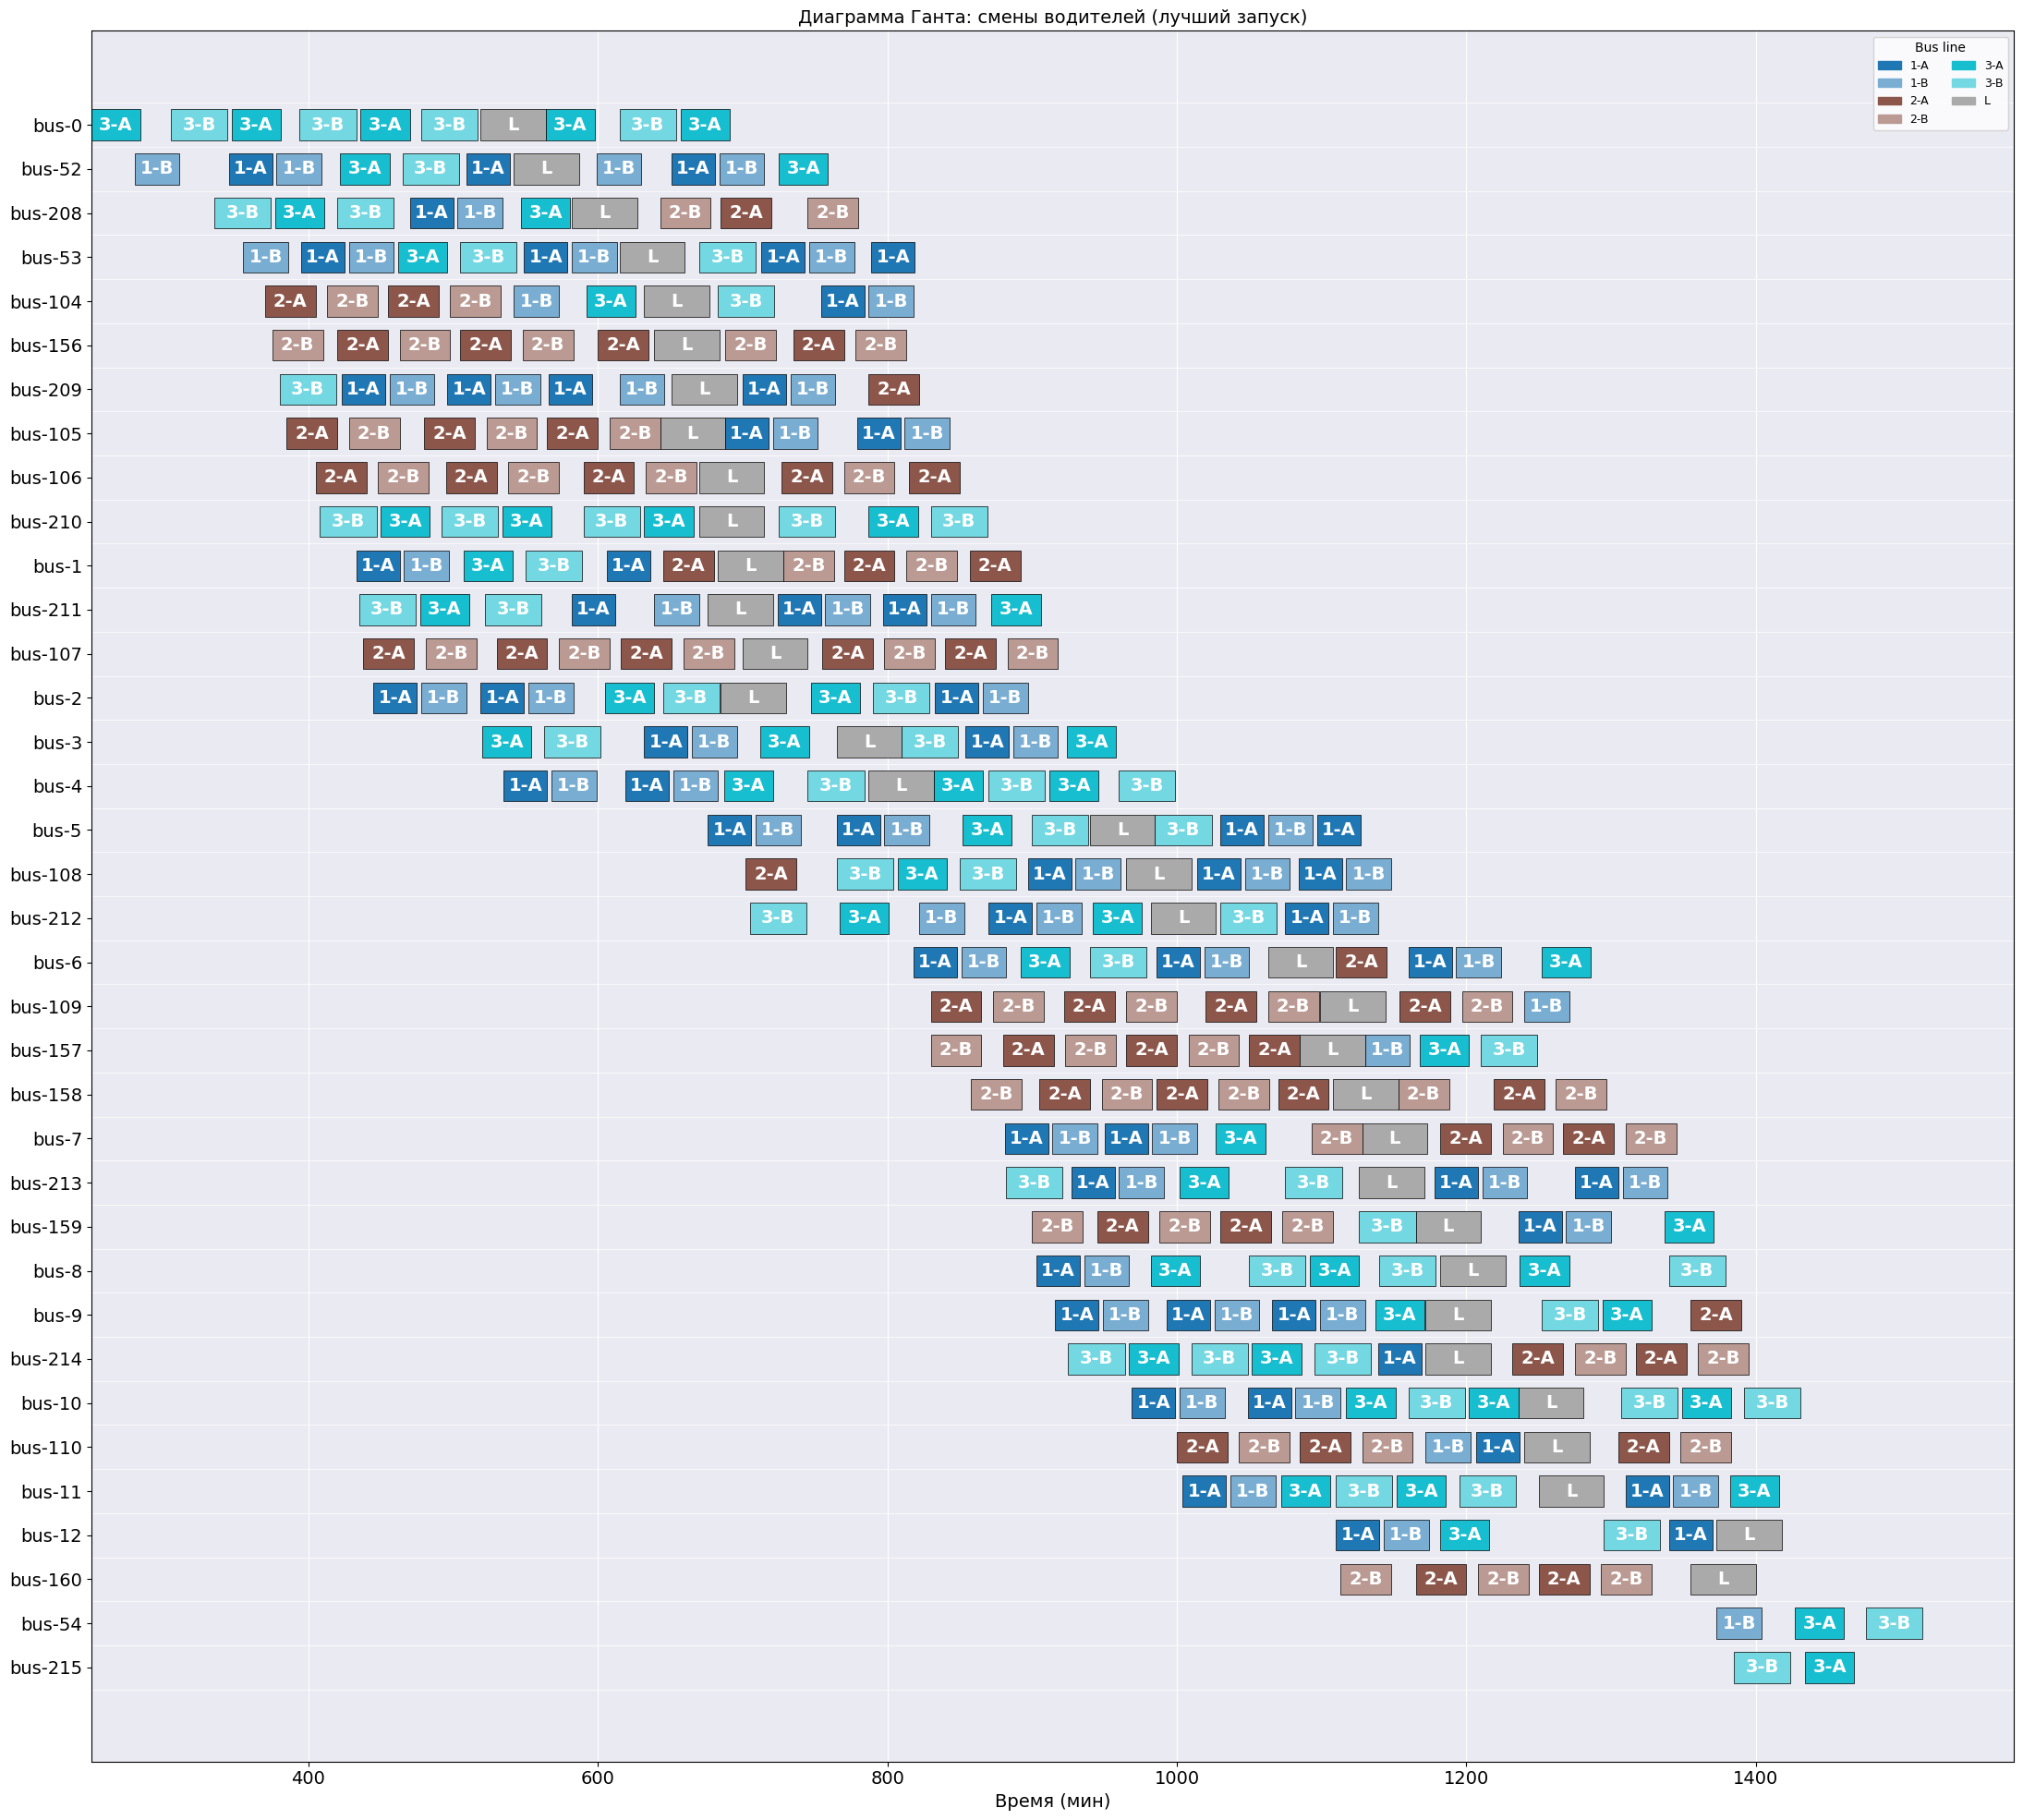

In [84]:
env = Environment(env_config)
routes_info = env.get_routes_info()
plot_gantt(val_result.best_shifts, routes_info)